# Margin model — predicting HOW MUCH a candidate wins by

**Completely separate from `model.ipynb`** (the win/lose classifier): separate notebook,
separate tuned hyperparameters, separate saved artifact (`data/margin_model_xgb.json`).

**Why this model exists:** for win/lose, the poll leader is already right ~87% of the time —
polls are the ceiling. But polls do NOT already contain *how far off they themselves will be*.
Predicting the actual victory margin is where fundamentals (incumbency, prior results,
national environment, economy) get a fair test.

**Target:** `margin_actual` = candidate's actual vote % minus the best opponent's actual
vote % (positive = won by that much). Same leak-free features from `features.py`; the
`vote_pct` label is used ONLY as the target, never as a feature.

**Validation:** identical nested scheme to the win model — tune on 1998–2016, honest
leave-one-cycle-out evaluation on 2018–2024.

In [1]:
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

from cycles import CYCLES, TUNE_CYCLES, EVAL_CYCLES, natl_env
import features as F
from macro_features import build_macro

pd.set_option('display.max_columns', 60)
print('xgboost', xgb.__version__)

xgboost 3.2.0


In [2]:
d = pd.read_csv('polls_long_with_results.csv', low_memory=False)
d = d[d['has_result'] == 1].copy()
d = F.prepare_polls(d)
d = d[d['year'].isin(CYCLES)].copy()
d['race_id'] = (d['year'].astype(str) + '_' + d['state'] + '_' + d['office']
                + d['district'].radd('-').where(d['district'] != '', ''))
print('poll rows:', len(d), '| races:', d['race_id'].nunique())

poll rows: 32026 | races: 1979


In [3]:
FUNDS = F.load_fundamentals()
NATL_ENV = natl_env()
FEC = F.load_fec()
BIAS = F.compute_bias_priors(d)
macro = build_macro()
MACRO_FEATS = sorted({k for cyc in macro for k in macro[cyc]})
FEATURES = F.feature_list(MACRO_FEATS, fund=True)
print('features:', len(FEATURES), '| macro:', len(MACRO_FEATS))

features: 186 | macro: 144


In [4]:
# candidate table + leak-free folds (same construction as the win model)
BASE = F.build_candidate_table(d, macro, NATL_ENV, FUNDS, house_train_years=CYCLES, fec=FEC, bias_priors=BIAS)

def add_margin_target(c):
    c = c.copy()
    mx = c.groupby('race_id')['vote_pct'].transform('max')
    def second(s):
        return s.nlargest(2).iloc[-1] if len(s) > 1 else np.nan
    m2 = c.groupby('race_id')['vote_pct'].transform(second)
    best_other = np.where(c['vote_pct'] >= mx, m2, mx)
    c['margin_actual'] = c['vote_pct'] - best_other
    return c[c['margin_actual'].notna()]

def fold_table(test_year):
    house = F.compute_house_effect(d, [y for y in CYCLES if y != test_year])
    adj = F.candidate_poll_adj(d, house).rename('poll_adj').reset_index()
    c = BASE.drop(columns='poll_adj').merge(adj, on=['race_id', 'cand_key'], how='left')
    return add_margin_target(c)

FOLDS = {ty: fold_table(ty) for ty in CYCLES}
cand = FOLDS[2024]

# sanity: sign of actual margin must almost always agree with the win label
agree = ((cand['margin_actual'] > 0).astype(int) == cand['won']).mean()
print('candidate rows with margin target:', len(cand))
print('sign(margin) agrees with won:', round(agree, 4))
# ~3-4% legit disagreement: RCV races (AK) and runoff states, where the
# first-round vote leader can lose. The margin target is still well-defined.
assert agree > 0.95, 'margin target inconsistent with win labels'
print('margin distribution:', cand['margin_actual'].describe().round(1).to_dict())

candidate rows with margin target: 4411
sign(margin) agrees with won: 0.9723
margin distribution: {'count': 4411.0, 'mean': -5.8, 'std': 25.9, 'min': -76.9, '25%': -19.1, '50%': -2.6, '75%': 10.4, 'max': 76.9}


In [5]:
# ---- nested tuning: XGBRegressor, scored by MAE over the 1998-2016 cycles ----
import itertools, random

def cv_mae(params, test_cycles):
    maes = []
    for ty in test_cycles:
        c = FOLDS[ty]
        tr = c[c['year'] != ty]; te = c[c['year'] == ty]
        m = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, **params)
        m.fit(tr[FEATURES], tr['margin_actual'])
        maes.append(mean_absolute_error(te['margin_actual'], m.predict(te[FEATURES])))
    return float(np.mean(maes))

GRID = dict(max_depth=[2, 3], learning_rate=[0.02, 0.03, 0.05],
            n_estimators=[200, 400], min_child_weight=[8, 15, 30],
            subsample=[0.6, 0.8, 1.0], colsample_bytree=[0.4, 0.6, 1.0],
            reg_lambda=[1, 5, 20], reg_alpha=[0, 1])
keys = list(GRID)
combos = list(itertools.product(*[GRID[k] for k in keys]))
random.seed(0); random.shuffle(combos); combos = combos[:120]

best = None
for combo in combos:
    p = dict(zip(keys, combo))
    mae = cv_mae(p, TUNE_CYCLES)
    if best is None or mae < best[0]:
        best = (mae, p)

XGBR_PARAMS = dict(best[1], objective='reg:squarederror', random_state=42)
print(f'best TUNE-cycle MAE (1998-2016): {best[0]:.3f} pts')
print('XGBR_PARAMS =', best[1])

best TUNE-cycle MAE (1998-2016): 7.228 pts
XGBR_PARAMS = {'max_depth': 3, 'learning_rate': 0.02, 'n_estimators': 400, 'min_child_weight': 15, 'subsample': 0.6, 'colsample_bytree': 0.6, 'reg_lambda': 1, 'reg_alpha': 1}


In [6]:
# ---- HONEST eval: leave-one-cycle-out on 2018-2024 (tuner never saw these) ----
# Baselines:
#   raw poll margin      : predicted margin = avg_margin_over_time (the polls' own answer)
#   calibrated poll marg : linear fit  margin_actual ~ avg_margin_over_time  on train cycles
rows, preds = [], {}
for ty in EVAL_CYCLES:
    c = FOLDS[ty]
    tr = c[c['year'] != ty]; te = c[c['year'] == ty].copy()

    m = xgb.XGBRegressor(**XGBR_PARAMS)
    m.fit(tr[FEATURES], tr['margin_actual'])
    te['pred_model'] = m.predict(te[FEATURES])

    te['pred_poll'] = te['avg_margin_over_time']
    fit_tr = tr.dropna(subset=['avg_margin_over_time'])
    lin = LinearRegression().fit(fit_tr[['avg_margin_over_time']], fit_tr['margin_actual'])
    x = te[['avg_margin_over_time']].fillna(0.0)
    te['pred_lin'] = lin.predict(x)

    def acc(col):
        pick = te.loc[te.groupby('race_id')[col].idxmax()]
        return pick['won'].mean()
    rows.append(dict(
        cycle=ty, n=len(te),
        MAE_model=mean_absolute_error(te['margin_actual'], te['pred_model']),
        MAE_poll=mean_absolute_error(te.dropna(subset=['pred_poll'])['margin_actual'],
                                     te['pred_poll'].dropna()),
        MAE_lin=mean_absolute_error(te['margin_actual'], te['pred_lin']),
        R2_model=r2_score(te['margin_actual'], te['pred_model']),
        acc_model=acc('pred_model'), acc_poll=acc('poll_avg'),
    ))
    preds[ty] = te

ev = pd.DataFrame(rows).set_index('cycle')
print('=== HONEST margin eval (LOCO 2018-2024), margins in percentage points ===')
print(ev.round(3).to_string())
print('\nMEAN:')
print(ev.mean().round(3).to_string())
print('\nMAE_model < MAE_lin < MAE_poll would mean features add real margin signal')

=== HONEST margin eval (LOCO 2018-2024), margins in percentage points ===
         n  MAE_model  MAE_poll  MAE_lin  R2_model  acc_model  acc_poll
cycle                                                                  
2018   636      6.136     8.013    7.685     0.873      0.868     0.885
2020   392      6.706     8.182    7.785     0.861      0.812     0.832
2022   478      6.354     8.155    7.730     0.882      0.862     0.897
2024   341      6.027     7.260    6.922     0.886      0.864     0.871

MEAN:
n            461.750
MAE_model      6.306
MAE_poll       7.903
MAE_lin        7.531
R2_model       0.875
acc_model      0.851
acc_poll       0.871

MAE_model < MAE_lin < MAE_poll would mean features add real margin signal


In [7]:
# where does the margin model win/lose vs the calibrated poll baseline?
allp = pd.concat(preds.values())
allp['err_model'] = (allp['pred_model'] - allp['margin_actual']).abs()
allp['err_lin']   = (allp['pred_lin']   - allp['margin_actual']).abs()
by_office = allp.groupby('office')[['err_model', 'err_lin']].mean().round(2)
print('MAE by office (model vs calibrated poll):')
print(by_office.to_string())
close = allp[allp['abs_gap'] < 5]
print('\nclose races only (polled gap < 5):')
print(close[['err_model', 'err_lin']].mean().round(2).to_string())

MAE by office (model vs calibrated poll):
          err_model  err_lin
office                      
Governor       5.39     7.67
House          6.92     7.79
Senate         5.37     6.93

close races only (polled gap < 5):
err_model    5.68
err_lin      6.71


wrote margin_feature_importance.csv


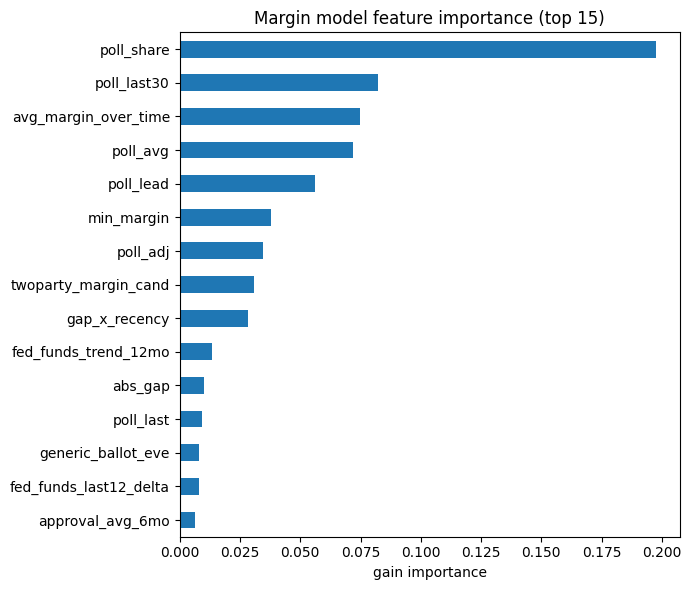

poll_share                0.1975
poll_last30               0.0822
avg_margin_over_time      0.0749
poll_avg                  0.0721
poll_lead                 0.0560
min_margin                0.0377
poll_adj                  0.0345
twoparty_margin_cand      0.0309
gap_x_recency             0.0281
fed_funds_trend_12mo      0.0136
abs_gap                   0.0100
poll_last                 0.0093
generic_ballot_eve        0.0081
fed_funds_last12_delta    0.0080
approval_avg_6mo          0.0065
dtype: float32

In [8]:
m_all = xgb.XGBRegressor(**XGBR_PARAMS)
train_all = add_margin_target(BASE)
m_all.fit(train_all[FEATURES], train_all['margin_actual'])

imp = pd.Series(m_all.feature_importances_, index=FEATURES).sort_values(ascending=False)
imp_df = imp.rename('gain_importance').reset_index().rename(columns={'index': 'feature'})
imp_df['rank'] = range(1, len(imp_df) + 1)
imp_df.to_csv('margin_feature_importance.csv', index=False)
print('wrote margin_feature_importance.csv')

top15 = imp.head(15).sort_values()
ax = top15.plot.barh(figsize=(7, 6), title='Margin model feature importance (top 15)')
ax.set_xlabel('gain importance')
plt.tight_layout(); plt.show()
imp.head(15).round(4)

In [9]:
# ---- PRODUCTION artifact (separate from the win model's) ----
import json
m_all.save_model('data/margin_model_xgb.json')
with open('data/margin_model_features.json', 'w') as f:
    json.dump({'features': FEATURES, 'macro_feats': MACRO_FEATS,
               'target': 'margin_actual (own vote_pct minus best opponent, pct points)',
               'trained_on_cycles': sorted(train_all['year'].unique().tolist()),
               'xgb_params': {k: v for k, v in XGBR_PARAMS.items()}}, f, indent=1)
print('saved data/margin_model_xgb.json + data/margin_model_features.json',
      f'({len(train_all)} rows, {train_all["race_id"].nunique()} races)')

saved data/margin_model_xgb.json + data/margin_model_features.json (4411 rows, 1964 races)


## Notes

- The interesting comparison is **MAE_model vs MAE_lin**: the linear baseline already fixes
  any constant bias/scale in the polled margin, so beating it means the *other* features
  (incumbency, prior margin, national environment, economy) carry real margin information.
- `acc_model` vs `acc_poll` shows whether better margins also flip winner calls.
- **Never** feed `vote_pct` / `margin_actual` / `race_winning_pct` as features — they are
  the outcome. The label flows through `features.py` as a passenger column only.
- Prediction on live races: `predict_margin.py` (same polling-agg feed as `predict.py`).